In [2]:
import os
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import time

In [3]:
load_dotenv()

True

In [4]:
llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0,
)

In [5]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [6]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [7]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)


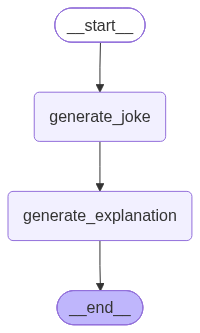

In [9]:
workflow

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with *dough*‑mestic experience and a *crust*‑worthy work ethic! 🍕😄',
 'explanation': '**The joke**\n\n> *Why did the pizza apply for a job?*  \n> *Because it heard the company was looking for someone with **dough‑mestic** experience and a **crust‑worthy** work ethic! 🍕😄*\n\n---\n\n## How the humor works\n\n1. **Set‑up and punchline**  \n   - The set‑up (“Why did the pizza apply for a job?”) creates an expectation that the answer will be about a pizza’s motivation—something silly or absurd.  \n   - The punchline delivers a *pun*: it swaps ordinary words for pizza‑related terms that sound almost the same.\n\n2. **Wordplay on “dough‑mestic”**  \n   - The phrase **“domestic experience”** is a common way to say “experience working at home or in a household setting.”  \n   - By inserting **“dough”** (the raw ingredient of pizza) we get **“dough‑mestic.”**  \n   - The joke p

In [11]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with *dough*‑mestic experience and a *crust*‑worthy work ethic! 🍕😄', 'explanation': '**The joke**\n\n> *Why did the pizza apply for a job?*  \n> *Because it heard the company was looking for someone with **dough‑mestic** experience and a **crust‑worthy** work ethic! 🍕😄*\n\n---\n\n## How the humor works\n\n1. **Set‑up and punchline**  \n   - The set‑up (“Why did the pizza apply for a job?”) creates an expectation that the answer will be about a pizza’s motivation—something silly or absurd.  \n   - The punchline delivers a *pun*: it swaps ordinary words for pizza‑related terms that sound almost the same.\n\n2. **Wordplay on “dough‑mestic”**  \n   - The phrase **“domestic experience”** is a common way to say “experience working at home or in a household setting.”  \n   - By inserting **“dough”** (the raw ingredient of pizza) we get **“dough‑mestic.”**

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?  \n\nBecause it was tired of being *filled* with secrets and always getting *deep‑fried* emotions! 😄', 'explanation': '**Explanation of the joke**\n\n| Part of the joke | What it literally means | The wordplay / pun |\n|------------------|------------------------|--------------------|\n| “Why did the **samosa** go to therapy?” | A samosa is a triangular Indian snack that’s usually stuffed with a savory filling. | The set‑up treats the food item as if it were a person who could have feelings and need a therapist. |\n| “Because it was **tired of being *filled* with secrets**” | A samosa is *filled* with potatoes, peas, spices, etc. | “Filled with secrets” plays on two ideas: <br>1. The literal filling inside the pastry. <br>2. The idiom “filled with secrets,” meaning someone is keeping a lot of hidden information. The joke pretends the samosa is emotionally burdened by the “secrets” it carries inside. |\

In [14]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f19ba44-cc75-6890-8000-fa0ae8904cf5"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f19ba44-cc75-6890-8000-fa0ae8904cf5'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-19T08:02:19.027012+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19ba44-cc6f-63ea-bfff-69def0c27635'}}, tasks=(PregelTask(id='e888e23b-05f7-fddf-aef8-31113a9bb124', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with *dough*‑mestic experience and a *crust*‑worthy work ethic! 🍕😄'}),), interrupts=())

In [15]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f19ba44-cc75-6890-8000-fa0ae8904cf5"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with *dough*‑mestic experience and a *crust*‑worthy work ethic! 🍕😄',
 'explanation': '**The Joke**\n\n> *Why did the pizza apply for a job?*  \n> *Because it heard the company was looking for someone with **dough‑mestic** experience and a **crust‑worthy** work ethic! 🍕😄*\n\n---\n\n## 1. How a Joke Works  \n\nA classic joke has two parts:\n\n| Part | What it does |\n|------|--------------|\n| **Set‑up** | Introduces a situation that seems ordinary, creating an expectation. |\n| **Punchline** | Subverts that expectation with a surprise—often a play on words (a *pun*) or an absurd twist. |\n\nIn this joke the set‑up is the question about a pizza looking for a job. The punchline delivers the surprise by turning ordinary hiring language into pizza‑related puns.\n\n---\n\n## 2. The Wordplay (Puns)\n\n### a. “dough‑mestic experience”\n\n| Original phrase | Meaning in a real‑

In [17]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f19ba44-cc75-6890-8000-fa0ae8904cf5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19ba4c-bb15-6646-8001-24b5b5abff78'}}

In [20]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f19ba4c-bb15-6646-8001-24b5b5abff78"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?  \n\nBecause it was tired of being *filled* with secrets and always getting *deep‑fried* emotions! 😄',
 'explanation': '**Explanation of the joke**\n\n| Part of the joke | What it literally means | The wordplay / pun |\n|------------------|------------------------|--------------------|\n| “Why did the **samosa** go to therapy?” | A samosa is a triangular Indian snack that’s usually stuffed with a savory filling. | The set‑up treats the food item as if it were a person who could have feelings and need a therapist. |\n| “Because it was **tired of being *filled* with secrets**” | A samosa is *filled* with potatoes, peas, spices, etc. | “Filled with secrets” plays on two ideas: <br>1. The literal filling inside the pastry. <br>2. The idiom “filled with secrets,” meaning someone is keeping a lot of hidden information. The joke pretends the samosa is emotionally burdened by the “secrets” it carries inside. |\n| “and always getti

In [4]:

class State(TypedDict):
    step: int
    log: list


In [5]:
def node_a(state: State):
    print("Running node_a...")
    return {"step": state["step"] + 1, "log": state["log"] + ["a done"]}


def node_b(state: State):
    print("Running node_b — sleeping 20s (try Ctrl+C here)...")
    time.sleep(20)
    return {"step": state["step"] + 1, "log": state["log"] + ["b done"]}


def node_c(state: State):
    print("Running node_c...")
    return {"step": state["step"] + 1, "log": state["log"] + ["c done"]}

In [6]:
builder = StateGraph(State)
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)
builder.set_entry_point("a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", END)

checkpointer = InMemorySaver()

workflow = builder.compile(checkpointer=checkpointer)

In [7]:
config1 = {"configurable": {"thread_id": "1"}}

In [8]:
try:
    result = workflow.invoke({"step": 0, "log": []}, config=config1)
    print("Finished:", result)
except KeyboardInterrupt:
    print("\nInterrupted. Re-run this script to resume from the last checkpoint.")

Running node_a...
Running node_b — sleeping 20s (try Ctrl+C here)...

Interrupted. Re-run this script to resume from the last checkpoint.


In [17]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'step': 3, 'log': ['a done', 'b done', 'c done']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19ba88-4798-618c-8003-0398cc6d5cc6'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-19T08:32:30.456173+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19ba88-478a-6d91-8002-89a042eecaa0'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'step': 2, 'log': ['a done', 'b done']}, next=('c',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19ba88-478a-6d91-8002-89a042eecaa0'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-19T08:32:30.450726+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19ba82-e2fd-652b-8001-7d1e89872fb7'}}, tasks=(PregelTask(id='cfae1de1-5058-bab9-4379-3f6791fa6323', name='c', path=('__pregel_pull', 'c'), erro

In [18]:
result = workflow.invoke(None, config=config1)